# Ames Housing — House Price Prediction

A complete machine learning pipeline for the Kaggle Ames Housing regression problem.

This notebook consolidates the final approach developed across the experimental versions: feature engineering, log-transformed target, outlier handling, 5-fold cross-validation, XGBoost, CatBoost, and OOF-based ensemble weighting.

## 1. Problem

The goal is to predict residential house sale prices from property characteristics. The target is `SalePrice` and the Kaggle test set contains the same predictors without the target.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor
from catboost import CatBoostRegressor

print('Libraries loaded.')

Libraries loaded.


In [3]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print('Train shape:', train.shape)
print('Test shape :', test.shape)
display(train.head())

Train shape: (1460, 81)
Test shape : (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 2. Exploratory Data Analysis

In [4]:
print('Target statistics:')
display(train['SalePrice'].describe())

missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
display(missing.head(20))

Target statistics:


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

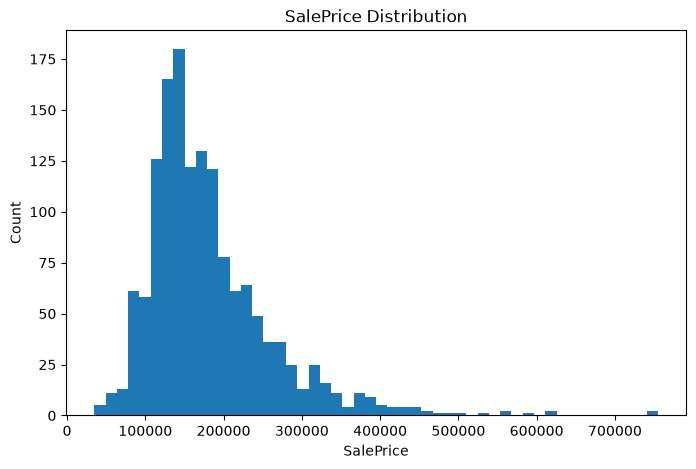

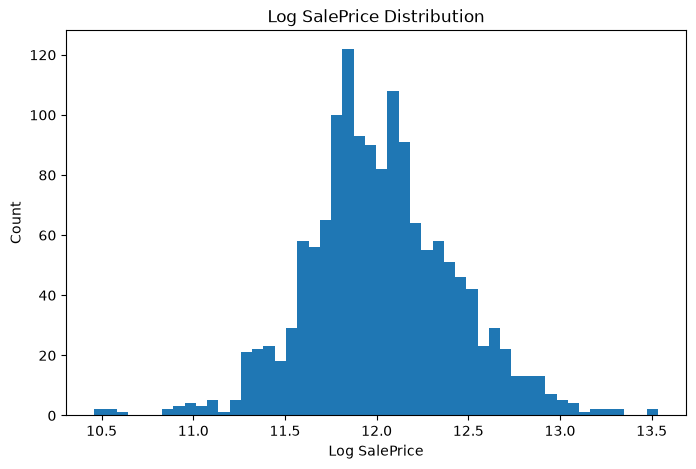

In [5]:
plt.figure(figsize=(8, 5))
plt.hist(train['SalePrice'], bins=50)
plt.xlabel('SalePrice')
plt.ylabel('Count')
plt.title('SalePrice Distribution')
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(np.log1p(train['SalePrice']), bins=50)
plt.xlabel('Log SalePrice')
plt.ylabel('Count')
plt.title('Log SalePrice Distribution')
plt.show()

## 3. Feature Engineering

The final feature set adds aggregated measures for total living space, bathrooms, porch area, total finished square footage, and property age. Interaction features capture the relationship between quality and living space.

In [6]:
def feature_engineering(df):
    df = df.copy()

    df['TotalSF'] = (
        df['TotalBsmtSF'].fillna(0)
        + df['1stFlrSF'].fillna(0)
        + df['2ndFlrSF'].fillna(0)
    )

    df['TotalBathrooms'] = (
        df['FullBath'].fillna(0)
        + 0.5 * df['HalfBath'].fillna(0)
        + df['BsmtFullBath'].fillna(0)
        + 0.5 * df['BsmtHalfBath'].fillna(0)
    )

    df['TotalPorchSF'] = (
        df['OpenPorchSF'].fillna(0)
        + df['3SsnPorch'].fillna(0)
        + df['EnclosedPorch'].fillna(0)
        + df['ScreenPorch'].fillna(0)
        + df['WoodDeckSF'].fillna(0)
    )

    df['Total_sqr_footage'] = (
        df['BsmtFinSF1'].fillna(0)
        + df['BsmtFinSF2'].fillna(0)
        + df['1stFlrSF'].fillna(0)
        + df['2ndFlrSF'].fillna(0)
    )

    df['HouseAge'] = df['YrSold'] - df['YearBuilt']
    df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']
    df['GarageAge'] = df['YrSold'] - df['GarageYrBlt']

    df['OverallQual_GrLivArea'] = df['OverallQual'] * df['GrLivArea']
    df['OverallQual_TotalSF'] = df['OverallQual'] * df['TotalSF']

    df['TotalSF'] = df['TotalSF'].clip(lower=0)
    df['HouseAge'] = df['HouseAge'].clip(lower=0)
    df['RemodAge'] = df['RemodAge'].clip(lower=0)
    df['GarageAge'] = df['GarageAge'].clip(lower=0)

    return df

In [7]:
train_fe = feature_engineering(train)
test_fe = feature_engineering(test)

outlier_mask = (
    (train_fe['GrLivArea'] > 4000)
    & (train_fe['SalePrice'] < 300000)
)

print('Potential outliers:')
display(train_fe.loc[outlier_mask, ['Id', 'GrLivArea', 'SalePrice']])

train_fe = train_fe.loc[~outlier_mask].reset_index(drop=True)

print('Train shape after outlier removal:', train_fe.shape)

Potential outliers:


,Id,GrLivArea,SalePrice
523,524,4676,184750
1298,1299,5642,160000


Train shape after outlier removal: (1458, 90)


## 4. Data Preparation

`SalePrice` is modeled on the `log1p` scale. Numeric missing values are filled with training-set medians and categorical missing values are represented by `Missing`. One-hot encoding is used for the XGBoost pipeline.

In [8]:
X = train_fe.drop(columns=['SalePrice'])
y = np.log1p(train_fe['SalePrice'])
X_test = test_fe.copy()

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(exclude=['object']).columns.tolist()

print('Categorical columns:', len(categorical_cols))
print('Numerical columns  :', len(numeric_cols))

Categorical columns: 43
Numerical columns  : 46


C:\Users\Danial\AppData\Local\Temp\ipykernel_7840\1297316029.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns.tolist()


In [9]:
for col in categorical_cols:
    X[col] = X[col].fillna('Missing')
    X_test[col] = X_test[col].fillna('Missing')

for col in numeric_cols:
    median = X[col].median()
    X[col] = X[col].fillna(median)
    X_test[col] = X_test[col].fillna(median)

print('Missing values in X:', X.isna().sum().sum())
print('Missing values in test:', X_test.isna().sum().sum())

Missing values in X: 0
Missing values in test: 0


## 5. 5-Fold Cross-Validation

In [10]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_xgb = np.zeros(len(X))
oof_cat = np.zeros(len(X))
test_xgb = np.zeros(len(X_test))
test_cat = np.zeros(len(X_test))

## 6. XGBoost + CatBoost

The two models use complementary tree-boosting approaches. Out-of-fold predictions are collected for an unbiased comparison and for selecting the ensemble weight.

In [11]:
for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
    print(f'\n========== Fold {fold} ==========')

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]
    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    preprocessor = ColumnTransformer([
        ('num', 'passthrough', numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

    xgb_model = XGBRegressor(
        n_estimators=1600,
        learning_rate=0.02,
        max_depth=3,
        min_child_weight=1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.01,
        reg_lambda=5,
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    )

    xgb_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', xgb_model)
    ])

    xgb_pipeline.fit(X_train, y_train)
    xgb_val_pred = xgb_pipeline.predict(X_val)
    xgb_test_pred = xgb_pipeline.predict(X_test)

    oof_xgb[val_idx] = xgb_val_pred
    test_xgb += xgb_test_pred / 5

    xgb_fold_rmse = np.sqrt(mean_squared_error(y_val, xgb_val_pred))
    print(f'XGBoost RMSE: {xgb_fold_rmse:.5f}')

    cat_model = CatBoostRegressor(
        iterations=2000,
        learning_rate=0.02,
        depth=6,
        loss_function='RMSE',
        l2_leaf_reg=5,
        random_seed=42,
        verbose=False
    )

    cat_model.fit(X_train, y_train, cat_features=categorical_cols)
    cat_val_pred = cat_model.predict(X_val)
    cat_test_pred = cat_model.predict(X_test)

    oof_cat[val_idx] = cat_val_pred
    test_cat += cat_test_pred / 5

    cat_fold_rmse = np.sqrt(mean_squared_error(y_val, cat_val_pred))
    print(f'CatBoost RMSE: {cat_fold_rmse:.5f}')


========== Fold 1 ==========
XGBoost RMSE: 0.12022
CatBoost RMSE: 0.11643

========== Fold 2 ==========
XGBoost RMSE: 0.11056
CatBoost RMSE: 0.10819

========== Fold 3 ==========
XGBoost RMSE: 0.12079
CatBoost RMSE: 0.11939

========== Fold 4 ==========
XGBoost RMSE: 0.11983
CatBoost RMSE: 0.12306

========== Fold 5 ==========
XGBoost RMSE: 0.10382
CatBoost RMSE: 0.10285


## 7. OOF Model Comparison

In [12]:
xgb_oof_rmse = np.sqrt(mean_squared_error(y, oof_xgb))
cat_oof_rmse = np.sqrt(mean_squared_error(y, oof_cat))

results = pd.DataFrame({
    'Model': ['XGBoost', 'CatBoost'],
    'OOF RMSE': [xgb_oof_rmse, cat_oof_rmse]
})
display(results)

,Model,OOF RMSE
0,XGBoost,0.115244
1,CatBoost,0.114226


## 8. OOF Ensemble

The ensemble weight is selected directly from the OOF predictions. This searches XGBoost weights from 0 to 1 in increments of 0.01.

In [13]:
best_rmse = float('inf')
best_weight = 0

for weight in np.arange(0, 1.001, 0.01):
    ensemble_pred = weight * oof_xgb + (1 - weight) * oof_cat
    rmse = np.sqrt(mean_squared_error(y, ensemble_pred))
    if rmse < best_rmse:
        best_rmse = rmse
        best_weight = weight

ensemble_oof = best_weight * oof_xgb + (1 - best_weight) * oof_cat
ensemble_mae = mean_absolute_error(y, ensemble_oof)
ensemble_r2 = r2_score(y, ensemble_oof)

print('==============================')
print('BEST ENSEMBLE')
print('==============================')
print(f'XGBoost Weight : {best_weight:.2f}')
print(f'CatBoost Weight: {1 - best_weight:.2f}')
print(f'Ensemble RMSE  : {best_rmse:.5f}')
print(f'Ensemble MAE   : {ensemble_mae:.5f}')
print(f'Ensemble R2    : {ensemble_r2:.5f}')

BEST ENSEMBLE
XGBoost Weight : 0.43
CatBoost Weight: 0.57
Ensemble RMSE  : 0.11278
Ensemble MAE   : 0.07649
Ensemble R2    : 0.92033


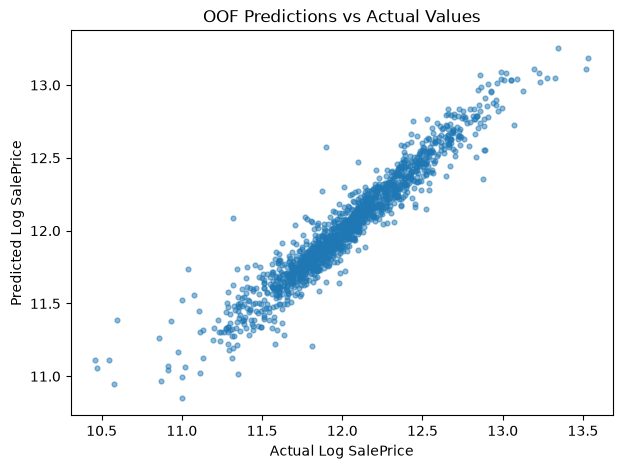

In [14]:
plt.figure(figsize=(7, 5))
plt.scatter(y, ensemble_oof, s=12, alpha=0.5)
plt.xlabel('Actual Log SalePrice')
plt.ylabel('Predicted Log SalePrice')
plt.title('OOF Predictions vs Actual Values')
plt.show()

## 9. Final Kaggle Prediction

The five fold test predictions are averaged for each model and combined using the best OOF ensemble weight. The predictions are then converted back from the log scale.

In [15]:
final_prediction_log = best_weight * test_xgb + (1 - best_weight) * test_cat
final_prediction = np.expm1(final_prediction_log)

submission = pd.DataFrame({
    'Id': test['Id'],
    'SalePrice': final_prediction
})

submission.to_csv('submission_final.csv', index=False)

print('Submission created: submission_final.csv')
display(submission.head())
display(submission['SalePrice'].describe())

Submission created: submission_final.csv


,Id,SalePrice
0,1461,120693.068727
1,1462,162090.415998
2,1463,179441.563277
3,1464,193707.654681
4,1465,185209.089430


count      1459.000000
mean     177155.959025
std       76693.378457
min       46985.403137
25%      127765.136908
50%      155656.998297
75%      206567.274847
max      596096.304851
Name: SalePrice, dtype: float64

## 10. Final Results

| Metric | Result |
|---|---:|
| XGBoost OOF RMSE | 0.11524 |
| CatBoost OOF RMSE | 0.11422 |
| Ensemble OOF RMSE | 0.11278 |
| Kaggle Score | 0.12431 |

The final submission used an XGBoost + CatBoost ensemble after feature engineering and removal of the identified extreme `GrLivArea` outliers.

## 11. Key Takeaways

- Log-transforming `SalePrice` makes the regression target easier to model for this competition metric.
- Feature engineering adds useful aggregate information about living area, bathrooms, porches, and property age.
- XGBoost and CatBoost provide complementary predictions.
- OOF predictions provide a consistent basis for selecting the ensemble weight.
- The final workflow produces a Kaggle-ready `submission_final.csv`.